In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,Biomass species,Moisture,Ash,Volatile_Matter,Fixed_Carbon,Carbon,Hydrogen,Oxygen,Nitrogen,Particle_Size,Temperature,Heating_Rate,Flow_Rate,Biochar_Yield,Bio_Oil_Yield,Gas_Yield
0,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.36,6.11,47.26,0.75,0.5,550,10.0,100.0,35.00,44.90,20.10
1,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.36,6.11,47.26,0.75,0.5,650,10.0,100.0,31.75,41.25,27.00
2,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.36,6.11,47.26,0.75,0.5,750,10.0,100.0,30.20,40.60,29.20
3,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.36,6.11,47.26,0.75,0.5,850,10.0,100.0,28.60,36.36,35.04
4,reed,5.89,8.47,72.12,13.52,42.78,5.17,50.51,1.33,0.5,550,10.0,100.0,32.85,54.38,12.77


In [13]:
df.shape

(715, 16)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Biomass species  715 non-null    str    
 1   Moisture         623 non-null    float64
 2   Ash              697 non-null    float64
 3   Volatile_Matter  647 non-null    float64
 4   Fixed_Carbon     647 non-null    float64
 5   Carbon           712 non-null    float64
 6   Hydrogen         712 non-null    float64
 7   Oxygen           712 non-null    float64
 8   Nitrogen         712 non-null    float64
 9   Particle_Size    644 non-null    float64
 10  Temperature      715 non-null    int64  
 11  Heating_Rate     638 non-null    float64
 12  Flow_Rate        570 non-null    float64
 13  Biochar_Yield    715 non-null    float64
 14  Bio_Oil_Yield    715 non-null    float64
 15  Gas_Yield        715 non-null    float64
dtypes: float64(14), int64(1), str(1)
memory usage: 89.5 KB


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Moisture,623.0,6.040626,5.188513,-100.00,4.900,5.70,7.360,22.74
Ash,697.0,6.007934,5.420382,0.24,2.200,4.87,7.300,29.51
Volatile_Matter,647.0,73.385564,10.206690,5.82,70.330,74.90,78.890,89.80
Fixed_Carbon,647.0,14.734853,6.362560,0.20,11.300,14.08,18.900,39.34
Carbon,712.0,47.766376,6.499083,22.49,44.410,47.20,52.250,66.65
Hydrogen,712.0,6.582051,1.744989,3.00,5.810,6.19,6.740,21.20
Oxygen,712.0,43.397598,7.933285,24.90,39.100,45.10,48.280,73.68
Nitrogen,712.0,2.624396,3.262513,0.00,0.750,1.53,3.900,22.50
Particle_Size,644.0,5.073261,24.204270,0.10,0.445,0.65,1.200,175.00
Temperature,715.0,512.818182,106.375849,300.00,450.000,500.00,550.000,900.00


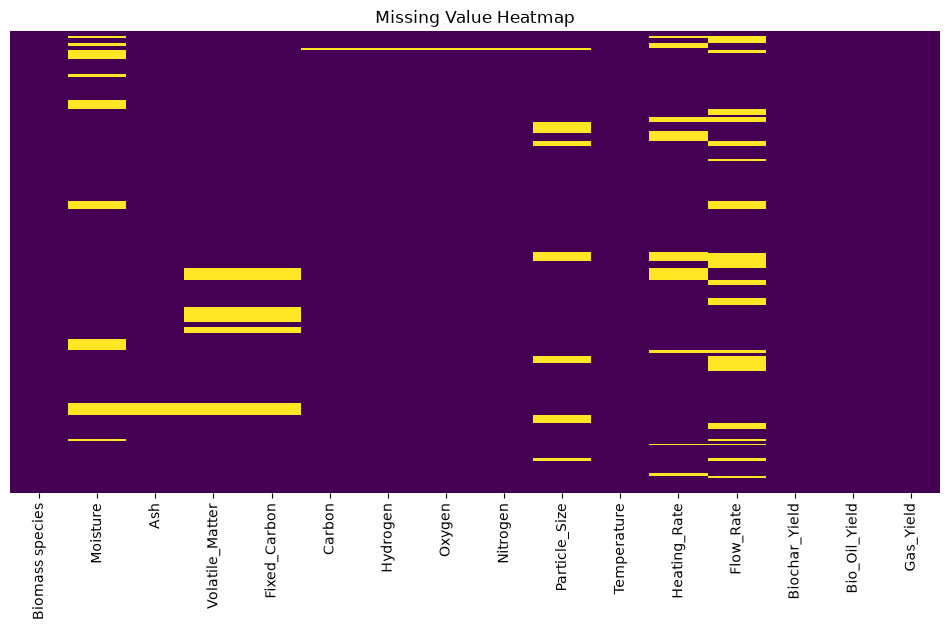

In [16]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

In [17]:
# Replace impossible moisture value
df["Moisture"] = df["Moisture"].replace(-100, np.nan)

# Replace impossible particle size
df["Particle_Size"] = df["Particle_Size"].replace(175, np.nan)

In [18]:
df[["Moisture", "Particle_Size"]].describe()

,Moisture,Particle_Size
count,622.000000,643.000000
mean,6.211109,4.808989
std,2.971134,23.274718
min,0.000000,0.100000
25%,4.900000,0.440000
50%,5.700000,0.650000
75%,7.360000,1.165000
max,22.740000,150.000000


In [19]:
num_cols = df.select_dtypes(include=np.number).columns

skewness = df[num_cols].skew().sort_values(ascending=False)
print(skewness)

Particle_Size      6.064014
Heating_Rate       4.291972
Flow_Rate          3.774118
Hydrogen           3.657652
Nitrogen           3.629777
Ash                1.944563
Moisture           1.359654
Fixed_Carbon       0.934399
Biochar_Yield      0.868303
Temperature        0.752998
Gas_Yield          0.341368
Carbon             0.057767
Bio_Oil_Yield     -0.207425
Oxygen            -0.229536
Volatile_Matter   -3.740209
dtype: float64


In [20]:
df[df["Particle_Size"] > 20][["Biomass species", "Particle_Size"]]

,Biomass species,Particle_Size
397,tobacco residues,150.0
398,tobacco residues,150.0
399,tobacco residues,150.0
400,tobacco residues,150.0
401,tobacco residues,150.0
402,tobacco residues,150.0
403,tobacco residues,150.0
404,tobacco residues,150.0
405,tobacco residues,150.0
406,tobacco residues,150.0


In [25]:
# -------------------------------
# Mean Imputation
# -------------------------------

mean_columns = [
    "Carbon",
    "Oxygen"
]

for col in mean_columns:
    df[col] = df[col].fillna(df[col].mean())


# -------------------------------
# Median Imputation
# -------------------------------

median_columns = [
    "Moisture",
    "Ash",
    "Volatile_Matter",
    "Fixed_Carbon",
    "Hydrogen",
    "Nitrogen",
    "Particle_Size",
    "Heating_Rate",
    "Flow_Rate"
]

for col in median_columns:
    df[col] = df[col].fillna(df[col].median())

In [27]:
df.loc[df["Particle_Size"] > 20, "Particle_Size"] = np.nan

df["Particle_Size"] = df["Particle_Size"].fillna(df["Particle_Size"].median())

In [28]:
df.isnull().sum()

Biomass species    0
Moisture           0
Ash                0
Volatile_Matter    0
Fixed_Carbon       0
Carbon             0
Hydrogen           0
Oxygen             0
Nitrogen           0
Particle_Size      0
Temperature        0
Heating_Rate       0
Flow_Rate          0
Biochar_Yield      0
Bio_Oil_Yield      0
Gas_Yield          0
dtype: int64

### Feature Selection

In [29]:
X = df.drop(
    columns=[
        "Bio_Oil_Yield",
        "Biochar_Yield",
        "Gas_Yield"
    ]
)

y = df["Bio_Oil_Yield"]

In [30]:
print(X.columns)

Index(['Biomass species', 'Moisture', 'Ash', 'Volatile_Matter', 'Fixed_Carbon',
       'Carbon', 'Hydrogen', 'Oxygen', 'Nitrogen', 'Particle_Size',
       'Temperature', 'Heating_Rate', 'Flow_Rate'],
      dtype='str')


In [31]:
X = pd.get_dummies(
    X,
    columns=["Biomass species"],
    drop_first=True,
    dtype=int
)

In [33]:
# Check the results
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print(X.head())

Feature matrix shape: (715, 104)
Target shape: (715,)
   Moisture   Ash  Volatile_Matter  Fixed_Carbon  Carbon  Hydrogen  Oxygen  \
0     15.76  3.34            67.40         13.50   45.36      6.11   47.26   
1     15.76  3.34            67.40         13.50   45.36      6.11   47.26   
2     15.76  3.34            67.40         13.50   45.36      6.11   47.26   
3     15.76  3.34            67.40         13.50   45.36      6.11   47.26   
4      5.89  8.47            72.12         13.52   42.78      5.17   50.51   

   Nitrogen  Particle_Size  Temperature  ...  Biomass species_spirulina  \
0      0.75            0.5          550  ...                          0   
1      0.75            0.5          650  ...                          0   
2      0.75            0.5          750  ...                          0   
3      0.75            0.5          850  ...                          0   
4      1.33            0.5          550  ...                          0   

   Biomass species_straw  

### Train Test Split

In [ ]:
%pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (572, 104)
Testing Features  : (143, 104)
Training Labels   : (572,)
Testing Labels    : (143,)


In [36]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/cleaned_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
